## Big Data For Health - Fall 2020 - Projest Group 6

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# tensorflow backend
from os import environ
environ['KERAS_BACKEND'] = 'tensorflow'
# import scientific py
import numpy as np
import pandas as pd
# rdkit stuff
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import PandasTools
# plotting stuff
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import SVG, display
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
# adding path with code to PATH variable
import sys
sys.path.insert(1, '/Users/user/Documents/BD4H/drug_discovery/2_new_molecule_generation/src')
# vae stuff
from processor.vae_utils import VAEUtils
from processor import mol_utils as mu

Using TensorFlow backend.


## Using the Variational Auto Encoder

smiles <i class="fa fa-arrow-right" aria-hidden="true"></i> x <i class="fa fa-arrow-right" aria-hidden="true"></i> z <i class="fa fa-arrow-right" aria-hidden="true"></i> x_r <i class="fa fa-arrow-right" aria-hidden="true"></i> smiles_r

In [3]:
# creating the variational autoencoder and loading the pretrained model
#sys.path.insert(2, '/Users/user/Documents/BD4H/drug_discovery/2_new_molecule_generation/model/pre-train/with_property')
print('Loading Pre-Trained Model...')
vae = VAEUtils(directory='./model/pre-train/with_property')
print('Model Loaded successfully..')

Loading Pre-Trained Model...
Using standarized functions? True
Standarization: estimating mu and std values ...done!
Model Loaded successfully..


# Prediction for For Cyclophosphamide(Compound)
Cyclophosphamide is an existing drug target which target BCL2

In [4]:
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Draw
# remove warnings and errors from notebook (lots of them due non valid molecule generation)
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

smiles_1 = mu.canon_smiles('C1CNP(=O)(OC1)N(CCCl)CCCl')

X_1 = vae.smiles_to_hot(smiles_1,canonize_smiles=True)
z_1 = vae.encode(X_1)
X_r= vae.decode(z_1)

print('{:20s} : {}'.format('Input',smiles_1))
print('{:20s} : {}'.format('Reconstruction',vae.hot_to_smiles(X_r,strip=True)[0]))

print('{:20s} : {} with norm {:.3f}'.format('Z representation',z_1.shape, np.linalg.norm(z_1)))

Input                : O=P1(N(CCCl)CCCl)NCCCO1
Reconstruction       : C#C1N=OC(SC)C(Cl)OCC1O1
Z representation     : (1, 196) with norm 14.022


In [5]:
print('Properties (qed,SAS,logP):')
y_1 = vae.predict_prop_Z(z_1)[0]
print(y_1)

Properties (qed,SAS,logP):
[0.71737796 4.004267   1.0098608 ]


Searching molecules randomly sampled from 5.00 std (z-distance) from the point
Found 1 unique mols, out of 1
SMILES
 0    OCP(=N)C(Cl)C(Cl)OC1CO1
Name: smiles, dtype: object


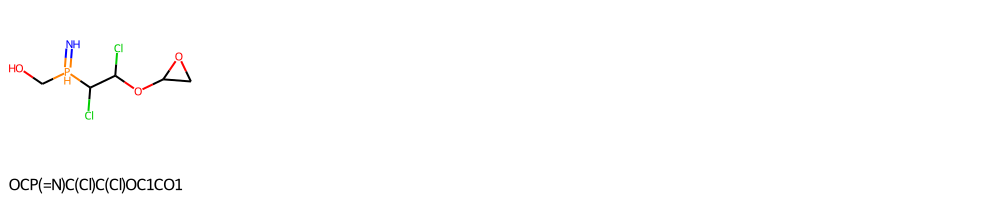

In [ ]:
noise=5.0
print('Searching molecules randomly sampled from {:.2f} std (z-distance) from the point'.format(noise))
df = vae.z_to_smiles( z_1,decode_attempts=200,noise_norm=noise)
print('Found {:d} unique mols, out of {:d}'.format(len(set(df['smiles'])),sum(df['count'])))
print('SMILES\n',df.smiles)
display(PandasTools.FrameToGridImage(df,column='mol', legendsCol='smiles',molsPerRow=5))
df.head()

In [47]:
pd.set_option('display.max_colwidth', -1)
Z, data, smiles = vae.ls_sampler_w_prop(size=50000,return_smiles=True)
prop_opt = 'qed'
prop_df = pd.DataFrame(data).reset_index()
prop_df['smiles']=smiles
prop_df.sort_values(by=['qed'], inplace=True)
prop_df.head()

,index,logP,qed,SAS,smiles
5668,153803,5.0442,0.125745,2.841685,O=C(COc1c(F)c(F)c(F)c(F)c1F)Oc1ccc2c(c1)O/C(=C\c1cccs1)C2=O
30954,29064,2.2135,0.154663,2.399324,N/C(CCCSc1ccccc1[N+](=O)[O-])=N\O
2636,27327,3.1920,0.155586,4.562625,O=C(COC(=O)c1ccccc1N1C(=O)[C@@H]2[C@H](C1=O)[C@@H]1C=C[C@H]2[C@@H]2C[C@H]12)c1ccc([N+](=O)[O-])cc1
6229,42452,3.4582,0.157361,2.437013,CC(C)NC(=O)c1cc2ccc(OC(=O)/C=C/c3cccc([N+](=O)[O-])c3)cc2oc1=O
34187,139207,5.4511,0.158518,2.401796,O=C(/C=C/c1cn(Cc2ccccc2)nc1-c1cccnc1)c1ccc(Cl)c([N+](=O)[O-])c1


In [48]:
def moltosvg(mol, molSize = (300,300), kekulize = True):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0],molSize[1])
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return svg.replace('svg:','')

In [50]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

smiles1 = 'O=C(COc1c(F)c(F)c(F)c(F)c1F)Oc1ccc2c(c1)O/C(=C\c1cccs1)C2=O' 
smiles2 = 'O=C(COc1c(F)c(F)c(F)c(F)c1F)Oc1ccc2c(c1)O/C(=C\c1cccs1)C2=O' 
smiles3 = 'O=C(COC(=O)c1ccccc1N1C(=O)[C@@H]2[C@H](C1=O)[C@@H]1C=C[C@H]2[C@@H]2C[C@H]12)c1ccc([N+](=O)[O-])cc1' 
smiles4 = 'CC(C)NC(=O)c1cc2ccc(OC(=O)/C=C/c3cccc([N+](=O)[O-])c3)cc2oc1=O' 
smiles5 = 'O=C(/C=C/c1cn(Cc2ccccc2)nc1-c1cccnc1)c1ccc(Cl)c([N+](=O)[O-])c1' 
m1 = Chem.MolFromSmiles(smiles1)
m2 = Chem.MolFromSmiles(smiles2)
m3 = Chem.MolFromSmiles(smiles3)
m4 = Chem.MolFromSmiles(smiles4)
m5 = Chem.MolFromSmiles(smiles5)

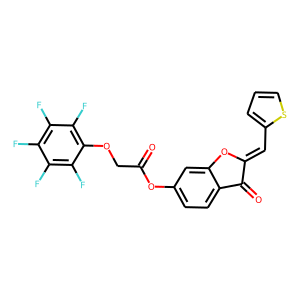

In [52]:
SVG(moltosvg(m1))

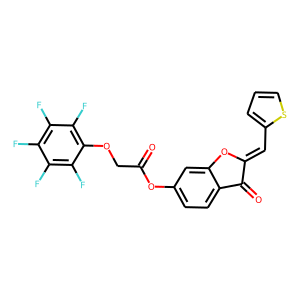

In [53]:
SVG(moltosvg(m2))

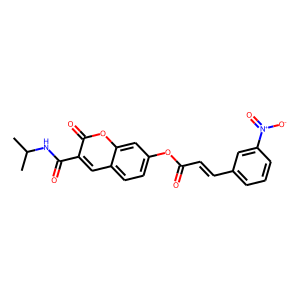

In [55]:
SVG(moltosvg(m4))

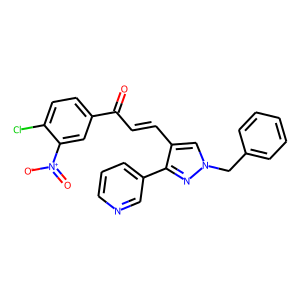

In [56]:
SVG(moltosvg(m5))

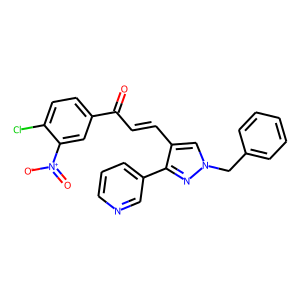

In [57]:
smiles6 = 'COc1cc2[nH]c(c([n+](c2cc1)[O-])C)=C(C(c3ccccc3)=O)C(=O)C(=O)c4ccccc4'
m6 = Chem.MolFromSmiles(smiles6)
SVG(moltosvg(m5))

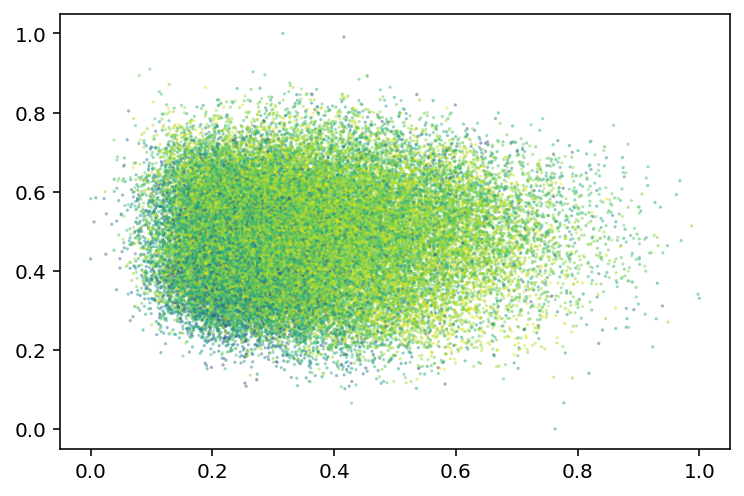

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# do pca and normalize
Z_pca = PCA(n_components=2).fit_transform(Z)
Z_pca = MinMaxScaler().fit_transform(Z_pca)

df = pd.DataFrame(np.transpose((Z_pca[:,0],Z_pca[:,1])))
df.columns = ['x','y']
df[prop_opt]=prop_df[prop_opt]

plt.scatter(x=df['x'], y=df['y'], c=df[prop_opt],
            cmap= 'viridis', marker='.',
            s=10,alpha=0.5, edgecolors='none')
plt.show()